# ILLUSTRATION OF GIBBS LEARNING IN A MISSPECIFIED MODEL SETTING

In [93]:
import numpy as np
import matplotlib.pyplot as plt

We illustrate the issues induced by misspecifying  a Bayesian model on a simple estimation task. We then showcase how Gibbs learning can provide an effective solution.

We consider data sampled from a mixture of gaussian distributions:
$$
Y \sim \alpha \mathcal{N}(0, 1) + (1 - \alpha) \mathcal{N}(0, \sigma^2)
$$

with $\alpha$ close to $1$ and $\sigma^2 >> 1$. This model generates a bulk of normally distributed samples with occasional outliers.

Our goal will be to estimate the true mean of this model equal to $0$.

In [103]:
# ---- Data-generating process ----
n = 100
sigma = 5
data = np.concatenate([
    np.random.normal(0, 1, int(0.9*n)),       # main normal bulk
    np.random.normal(0, sigma**2, int(0.1*n)) # few outliers
])

We recall the form of the Gibbs posterior: given a prior $\pi$ over parameters $\theta$, a loss $l$ and parameter $\eta$, the posterior writes:
$$
q(\theta|y) = \pi(\theta) exp(-\eta l(\theta, y))
$$

We start with a misspecified Bayesian model using a gaussian likelihood $p(y|\theta) = \mathcal{N}(\theta, 1)$ and gaussian prior $\pi(\theta) = \mathcal{N}(0, 1)$. This model can be seen as a Gibbs model with squared loss $l(\theta, y) = \frac{1}{2} ||y - \theta||^2$ and $\eta = 1$.

Next we specify a Gibbs model using the same prior and $\eta$ but exchanges the squared loss for the $\delta$-Huber loss:
- If $|y - \theta| < \delta$, $h(\theta, y) = \frac{1}{2} ||y - \theta||^2$
- If $|y - \theta| > \delta$, $h(\theta, y) = \delta |y - \theta| - \frac{1}{2} \delta$

This loss remains quadratic around $0$ and becomes linear outside the interval $[-\delta, \delta]$ granting it some robustness to outliers. This loss is especially useful when real-world assumptions can help choosing $\delta$.

In [95]:
theta_grid = np.linspace(-3, 3, 1000) # parameter grid, shape (N)

def squared_loss(theta, y):
    return 0.5 * (y - theta)**2

def huber_loss(theta, y, delta=1.5):
    r = y - theta
    return np.where(np.abs(r) <= delta, 0.5 * r**2, delta*np.abs(r) - 0.5*delta)

# ---- Prior ----
prior = np.exp(-0.5 * (theta_grid)**2) # shape (N)
prior /= prior.sum()

In [96]:
def estimate_mean(prior, data, theta, eta, loss):
    """
    OVERVIEW
    Computes the Gibbs estimator of the mean for our setup.
    
    INPUTS:
    - prior: np.array, dtype float, shape (N);
    - theta: np.array, dtype float, shape (N);
    - data:  np.array, dtype float, shape (D);
    - eta:   float;
    - loss:  function: theta, y -> float;

    OUTPUTS:
    - mean:      float;
    - posterior: np.array, dtype float, shape (N);
    """
    log_post = np.log(prior)

    # compute log-loss
    for y in data:
        log_post -= eta * loss(theta, y)

    post = np.exp(log_post - log_post.max()) # subtract max to avoid overflow (cancels with normalization)
    post /= post.sum()                       # normalize, shape (N)
    mean = np.sum(theta * post)

    return mean, post

In [97]:
eta = 1
eta_low = 0.005
eta_gibbs = 0.5

mean_bayes1, post_bayes1 = estimate_mean(prior, data, theta_grid, eta, squared_loss)
mean_bayes2, post_bayes2 = estimate_mean(prior, data, theta_grid, eta_low, squared_loss)
mean_gibbs, post_gibbs = estimate_mean(prior, data, theta_grid, eta_gibbs, huber_loss)

print("True mean = 0")
print(f"Bayes posterior mean with eta = {eta}:", mean_bayes1)
print(f"Bayes posterior mean with eta = {eta_low}:", mean_bayes2)
print(f"Huber posterior mean with eta = {eta_gibbs}:", mean_gibbs)

True mean = 0
Bayes posterior mean with eta = 1: -0.9751311283565774
Bayes posterior mean with eta = 0.005: -0.32684970763550336
Huber posterior mean with eta = 0.5: -0.17082589539494666


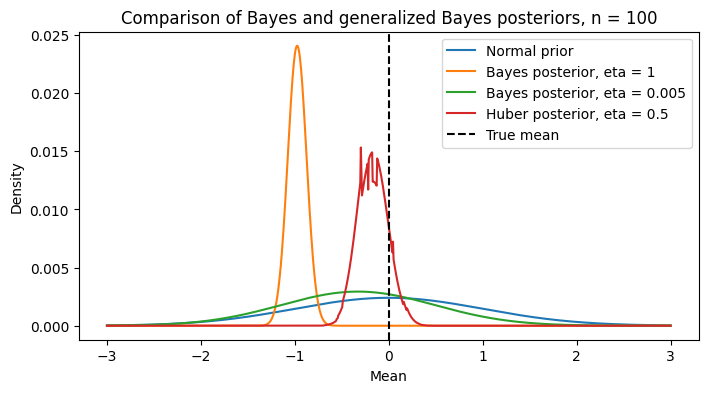

In [98]:
plt.figure(figsize=(8,4))
plt.plot(theta_grid, prior, label="Normal prior")
plt.plot(theta_grid, post_bayes1, label=f"Bayes posterior, eta = {eta}")
plt.plot(theta_grid, post_bayes2, label=f"Bayes posterior, eta = {eta_low}")
plt.plot(theta_grid, post_gibbs, label=f"Huber posterior, eta = {eta_gibbs}")
plt.axvline(0, color="k", linestyle="--", label="True mean")
plt.legend()
plt.ylabel("Density")
plt.xlabel("Mean")
plt.title(f"Comparison of Bayes and generalized Bayes posteriors, n = {n}")
plt.show()

The Bayesian model with gaussian likelihood suffers greatly from the presence of outliers and concentrates far from the true mean.

The tempered Bayesian model with small parameter $\eta$ remains closer to its prior. It is less sensitive to outliers at the cost of losing concentration. This is a case of low confidence in the data model, leading to entropy maximization.

The Huber Gibbs model leverages Huber loss' robustness to outliers and concentrates close to the true mean.

This simple example showcases the interest of generalized Bayes in misspecified setups using loss adaptation and confidence adjustment.

Finally, we showcase one last example with more data.

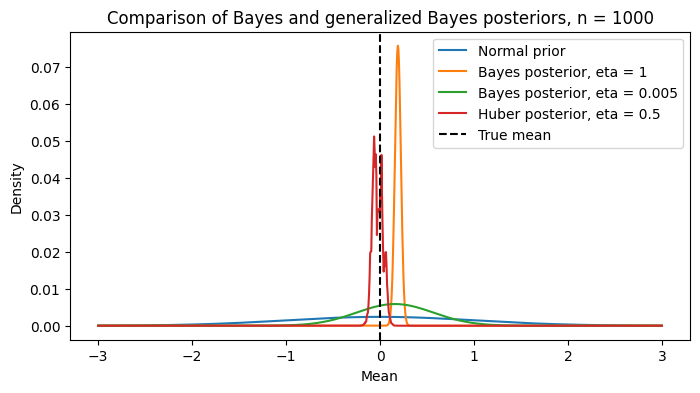

In [ ]:
n = 1000
data = np.concatenate([
    np.random.normal(0, 1, int(0.9*n)),
    np.random.normal(0, sigma**2, int(0.1*n))
])

mean_bayes1, post_bayes1 = estimate_mean(prior, data, theta_grid, eta, squared_loss)
mean_bayes2, post_bayes2 = estimate_mean(prior, data, theta_grid, eta_low, squared_loss)
mean_gibbs, post_gibbs = estimate_mean(prior, data, theta_grid, eta_gibbs, huber_loss)

plt.figure(figsize=(8,4))
plt.plot(theta_grid, prior, label="Normal prior")
plt.plot(theta_grid, post_bayes1, label=f"Bayes posterior, eta = {eta}")
plt.plot(theta_grid, post_bayes2, label=f"Bayes posterior, eta = {eta_low}")
plt.plot(theta_grid, post_gibbs, label=f"Huber posterior, eta = {eta_gibbs}")
plt.axvline(0, color="k", linestyle="--", label="True mean")
plt.legend()
plt.ylabel("Density")
plt.xlabel("Mean")
plt.title(f"Comparison of Bayes and generalized Bayes posteriors, n = {n}")
plt.show()

We see that more data benefits the standard Bayesian model well with drastic reduction in both bias and variance.

The tempered model appears mildly affected with reduced variance but similar bias.

However, standard Bayes keeps a significative bias compared to the Huber Gibbs model.